In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)


dates = pd.date_range(start='2021-01-01', end='2023-12-31', freq='D')

n = len(dates)


trend = np.linspace(100, 150, n)           
seasonality = 20 * np.sin(2 * np.pi * np.arange(n) / 365)  
noise = np.random.normal(0, 10, n)        

demand = trend + seasonality + noise
demand = np.clip(demand, 0, None)          


df = pd.DataFrame({
    'date': dates,
    'demand': demand.round(0)
})

df.head(10)

Matplotlib is building the font cache; this may take a moment.


,date,demand
0,2021-01-01,105.0
1,2021-01-02,99.0
2,2021-01-03,107.0
3,2021-01-04,116.0
4,2021-01-05,99.0
5,2021-01-06,100.0
6,2021-01-07,118.0
7,2021-01-08,110.0
8,2021-01-09,98.0
9,2021-01-10,109.0


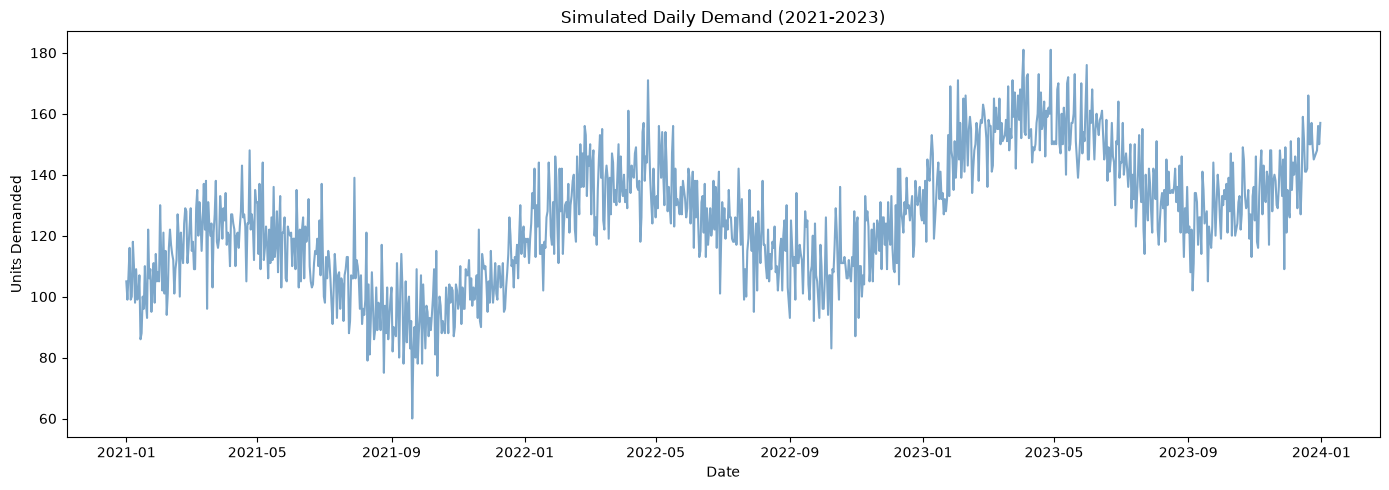

In [2]:
plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['demand'], alpha=0.7, color='steelblue')
plt.title('Simulated Daily Demand (2021-2023)')
plt.xlabel('Date')
plt.ylabel('Units Demanded')
plt.tight_layout()
plt.show()

In [ ]:
df['day_of_year'] = df['date'].dt.dayofyear
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter
df['year'] = df['date'].dt.year
df['day_of_week'] = df['date'].dt.dayofweek


df['lag_1'] = df['demand'].shift(1)
df['lag_7'] = df['demand'].shift(7)
df['lag_30'] = df['demand'].shift(30)


df['rolling_mean_7'] = df['demand'].shift(1).rolling(7).mean()
df['rolling_mean_30'] = df['demand'].shift(1).rolling(30).mean()


df = df.dropna()

df.head()

,date,demand,day_of_year,month,quarter,year,day_of_week,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30
30,2021-01-31,105.0,31,1,1,2021,6,108.0,95.0,105.0,105.000000,103.666667
31,2021-02-01,130.0,32,2,1,2021,0,105.0,104.0,99.0,106.428571,103.666667
32,2021-02-02,112.0,33,2,1,2021,1,130.0,111.0,107.0,110.142857,104.700000
33,2021-02-03,102.0,34,2,1,2021,2,112.0,98.0,116.0,110.285714,104.866667
34,2021-02-04,121.0,35,2,1,2021,3,102.0,114.0,99.0,110.857143,104.400000


In [ ]:

train = df[df['year'] < 2023]
test = df[df['year'] == 2023]

#
features = ['day_of_year', 'month', 'quarter', 'year', 
            'day_of_week', 'lag_1', 'lag_7', 'lag_30',
            'rolling_mean_7', 'rolling_mean_30']

target = 'demand'

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 700
Testing samples: 365


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


model = RandomForestRegressor(
    n_estimators=100,    
    random_state=42      
)

model.fit(X_train, y_train)


predictions = model.predict(X_test)


mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Mean Absolute Error (MAE): {mae:.2f} units")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} units")

Mean Absolute Error (MAE): 14.36 units
Root Mean Squared Error (RMSE): 17.25 units


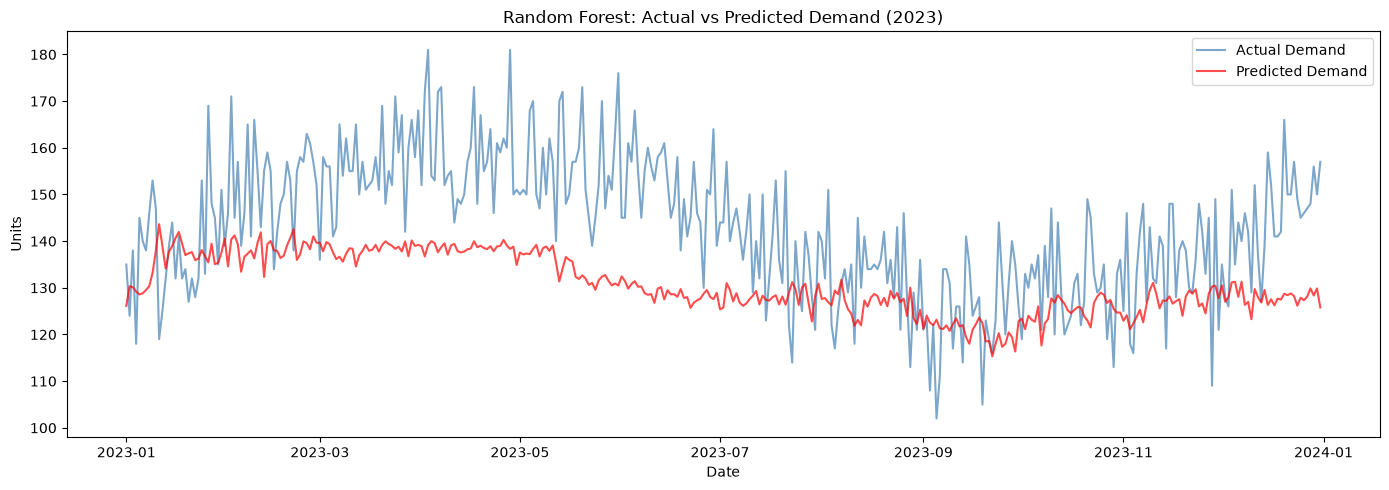

In [ ]:
plt.figure(figsize=(14, 5))


plt.plot(test['date'].values, y_test.values, 
         label='Actual Demand', color='steelblue', alpha=0.7)


plt.plot(test['date'].values, predictions, 
         label='Predicted Demand', color='red', alpha=0.7)

plt.title('Random Forest: Actual vs Predicted Demand (2023)')
plt.xlabel('Date')
plt.ylabel('Units')
plt.legend()
plt.tight_layout()
plt.show()

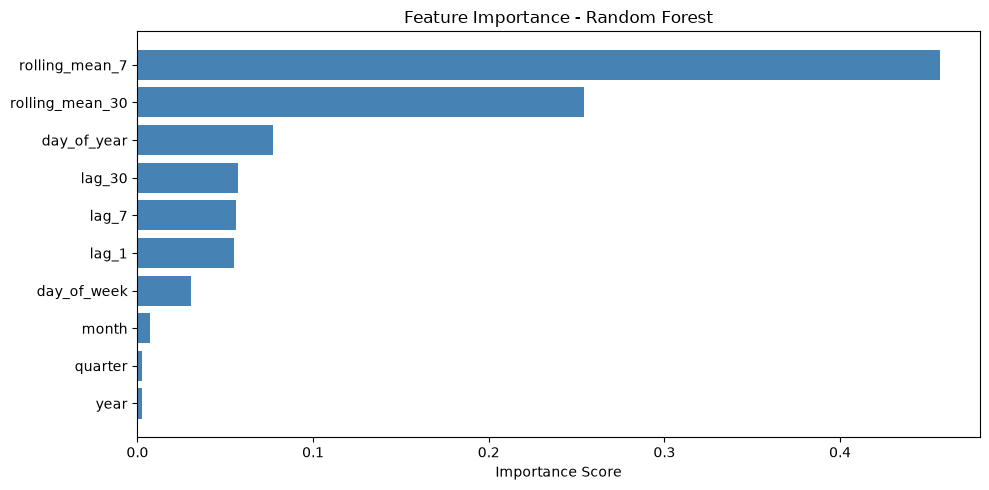

           feature  importance
8   rolling_mean_7    0.456831
9  rolling_mean_30    0.253964
0      day_of_year    0.077451
7           lag_30    0.057484
6            lag_7    0.056176
5            lag_1    0.054985
4      day_of_week    0.030321
1            month    0.007437
2          quarter    0.002683
3             year    0.002668


In [ ]:

importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(importance['feature'], importance['importance'], color='steelblue')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importance)

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,    
    max_depth=5,          
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))

print(f"XGBoost MAE: {xgb_mae:.2f} units")
print(f"XGBoost RMSE: {xgb_rmse:.2f} units")
print()
print(f"Random Forest MAE: {mae:.2f} units")
print(f"Random Forest RMSE: {rmse:.2f} units")

XGBoost MAE: 17.02 units
XGBoost RMSE: 19.83 units

Random Forest MAE: 14.36 units
Random Forest RMSE: 17.25 units


In [ ]:
import pickle
import os


os.makedirs('../outputs', exist_ok=True)

with open('../outputs/demand_forecast_model.pkl', 'wb') as f:
    pickle.dump(model, f)


results_df = test[['date', 'demand']].copy()
results_df['predicted_demand'] = predictions
results_df.to_csv('../outputs/forecast_results.csv', index=False)

print("Model saved successfully!")
print(f"Forecast results saved with {len(results_df)} rows")

Model saved successfully!
Forecast results saved with 365 rows
